#**Maestría en Inteligencia Artificial Aplicada**
##**Curso: Procesamiento de Lenguaje Natural (NLP)**
###Tecnológico de Monterrey
###Prof Luis Eduardo Falcón Morales

-----------------------------------------------------------
###Denisse Maria Ramirez Colmenero
###A01561497

-----------------------------------------------------------
## **Adtividad Semanas 03 y 04**

###**Pre-procesamiento, Matrices Documeto-Término (DTM) y TF-IDF.**


###Fecha: 15 de Mayo de 2023

En esta actividad deberás utilizar los datos de tres archivos que se encuentran en Canvas:

*   **amazon_cells_labelled.txt** Contiene 1000 registros de comentarios de usuarios que adquirieron un producto a través de la plataforma de Amazon.

*   **imdb_labelled.txt** Contiene 1000 registros de comentarios que dejaron usuarios sobre palículas y series en la plataforma de IMBD.

*   **yelp_labelled.txt** Contiene 1000 comentarios de usuarios sobre servicios de comida dejados en l aplataforma de Yelp.

Igualmente son los archivos que encuentras en el Machine Learning Repository de la UCI, llamado "Sentiment Labelled Sentences": https://archive.ics.uci.edu/ml/datasets/Sentiment+Labelled+Sentences#



In [2]:
import pandas as pd  
import numpy as np

import nltk
from nltk.corpus import stopwords

import re
import string

In [3]:
nltk.download('punkt')    # es un tokenizador que ayuda a dividr el texto en enunciados mediante un modelo no-supervisado.
nltk.download('stopwords')    # para tener acceso a "stopwords" en varios idiomas.

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
# Veamos la lista de stopwords que se incluyen de manera predeterminada la suite de librerías de NLTK:

print(len(stopwords.words('english')))
print(stopwords.words('english'))

179
['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than

In [5]:
# Consideremos la siguiente lista de palabras asociada a negaciones en inglés:

negwords = [ 'no', 'nor', 'not', 'ain', 'aren', "aren't", 'don', "don't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

In [6]:
type(negwords)

list

##**Pregunta - 1:**




Excluye todas las palabras de la lista "negwords" de la lista predeterminada de "stopwords", para definir un nuevo conjunto llamado **mystopwords**, con el cual trabajaremos en esta Actividad:


In [7]:
################################################################################
# AGREGA AQUÍ TU LÍNEA O LÍNEAS DE CÓDIGO - Pregunta 1:

mystopwords = [palabra for palabra in (stopwords.words('english')) if palabra not in negwords]
#si la palabra no esta en negwords, si la pone en la lista nueva

# FIN PARA AGREGAR TU LÍNEA O LÍNEAS DE CÓDIGO.
################################################################################

print(len(mystopwords))
print(mystopwords)

139
['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's

###**Cargamos los datos de Amazon**

In [8]:
# Puedes modificar en dado caso la ruta de los archivos:

dfa = pd.read_csv('amazon_cells_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')
dfi = pd.read_csv('imdb_labelled.txt', delimiter='\t', names=['review','label'], header=None, encoding='utf-8')
dfy = pd.read_csv('yelp_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')


print('Total de registros de Amazon:',dfa.shape)
print('Total de registros de IMBD:',dfi.shape)
print('Total de registros de Yelp:',dfy.shape)

Total de registros de Amazon: (1000, 2)
Total de registros de IMBD: (748, 2)
Total de registros de Yelp: (1000, 2)


La salida anterior esperada es la siguiente:

Total de registros de Amazon: (1000, 2)

Total de registros de IMBD: (748, 2)

Total de registros de Yelp: (1000, 2)

In [9]:
dfa.head()     # Cada uno de estos data frame está formado de dos columnas, 
               # uno con los comentarios (review) y otro con la etiqueta (label).
               # En particular aquí mostramos en el Amazon:

,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


Sin embargo, observa que los registros de IMBD no son los 1000 que se indican en la documentación de estos datos, sino 748. 

En realidad no son datos perdidos, sino que varios de ellos fueron capturados errónamente como uno solo. En ocasiones, la gran cantidad de caracteres especiales existentes en la actualidad generan este tipo de problemas.

Por ejemplo, observa la salida siguiente y cómo el registro de índice 19 tiene una gran cantidad de registros conjuntados como uno solo. Es decir, se conjuntó indebidamente información de las dos columnas del data frame.



In [10]:
dfi.values.tolist()[17:21]

[["I'll put this gem up against any movie in terms of screenplay, cinematography, acting, post-production, editing, directing, or any other aspect of film-making.  ",
  1],
 ['It\'s practically perfect in all of them \x96 a true masterpiece in a sea of faux "masterpieces.  ',
  1],
 [' The structure of this film is easily the most tightly constructed in the history of cinema.  \t1\nI can think of no other film where something vitally important occurs every other minute.  \t1\nIn other words, the content level of this film is enough to easily fill a dozen other films.  \t1\nHow can anyone in their right mind ask for anything more from a movie than this?  \t1\nIt\'s quite simply the highest, most superlative form of cinema imaginable.  \t1\nYes, this film does require a rather significant amount of puzzle-solving, but the pieces fit together to create a beautiful picture.  \t1\nThis short film certainly pulls no punches.  \t0\nGraphics is far from the best part of the game.  \t0\nThis is

Además, se observa que cada comentario (review) debe estar separado de su evaluación (label) por un tabulador "\t" y después separado del siguiente registro por un salto de línea "\n".

Usaremos esta información para separar de manera adecuada estos registros del conjunto de IMBD.

##**Pregunta - 2:**

En este ejercicio deberás corregir este problema que tienen los comentarios de IMBD, del cual se registran 748 comentarios, cuando deben ser 1000.

Como cada data frame tiene 2 columnas, el comentario y la evaluación, en algunas ocasiones el valor numérico de la evaluación se toma como parte del comentario y esto empieza a generar dichos errores. 

El problema se puede intentar resolver de varias formas, sin embargo puedes al menos seguir los siguientes pasos para obtener de nuevo los 1000 comentarios en IMBD:


1.   Conjuntar en un solo string cada comentario (review) con su evaluación (label), separados por un tabulador "\t". Toma en cuenta que ambos deben ser del tipo de dato string.

2.   Separa cada uno de estos string con el método split() y con respecto al salto de línea "\n". Esto te debe llevar a que cada registro es ahora una lista con un solo string que contiene el comenario (review), seguido del tabulador y de la etiqueta (label). O bien, tienes una lista de varios string, donde cada string es un review, seguido por el tabulador y su label.

3.   Ahora separa cada cada uno de los string del paso anterior con respecto al tabulador "\t", para ya tener separados ahora sí, todos los comentarios (review) de su evaluación (label). 

4.   Agrega cada uno de estos nuevos comentarios (review) y etiquetas (label) a la nueva lista que llamamos "newdfi".

El número de elementos de la nueva lista "newdfi" debe de ser de 1000, donde cada elemento está formado a su vez por una lista de dos elementos, donde el primero es un string del comentario (review) y el segundo es un número entero de la etiqueta (label).

Básicamente la idea fue conjuntar de nuevo la información de ambas columnas, para separarlas de nuevo de la manera adecuada.






In [11]:
tmpdfi = dfi.values.tolist()     # lista con los 748 registros.
newdfi=[]     # lista de salida que deberá tener los 1000 registros ya debidamente separados.

################################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 2:

#1. juntar el review, el \t y el label en un solo conjunto
for conjunto in tmpdfi:
  if '\n' not in conjunto[0]:
    newdfi.append(conjunto) #si un conjunto no empieza con el salto de linea, se agrega a la lista 
  else: 
    review= conjunto[0].split('\n') #2. despues de ese conjunto, los que siguen si empiezan con \n, entonces se separan a partir de ahi 
    for i in range(len(review)-1):
      reviewfinal = review[i].split('\t')#3. una vez esos conjuntos se separan respecto a \t
      newdfi.append([reviewfinal[0], int(reviewfinal[1])])#4. los review tienen dos elementos, los label deben ser tipo int 
    newdfi.append([review[len(review)-1], conjunto[1]])#5. agrega el string ya separado a la nueva lista
# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
################################################################################

print('La nueva lista tiene 1000 elementos:', len(newdfi)==1000)

La nueva lista tiene 1000 elementos: True


In [12]:
# Verificando los registros donde habíamos detectado uno de los problemas:
newdfi[17:21]

[["I'll put this gem up against any movie in terms of screenplay, cinematography, acting, post-production, editing, directing, or any other aspect of film-making.  ",
  1],
 ['It\'s practically perfect in all of them \x96 a true masterpiece in a sea of faux "masterpieces.  ',
  1],
 [' The structure of this film is easily the most tightly constructed in the history of cinema.  ',
  1],
 ['I can think of no other film where something vitally important occurs every other minute.  ',
  1]]

En particular la salida anterior debe ser algo como lo siguiente:

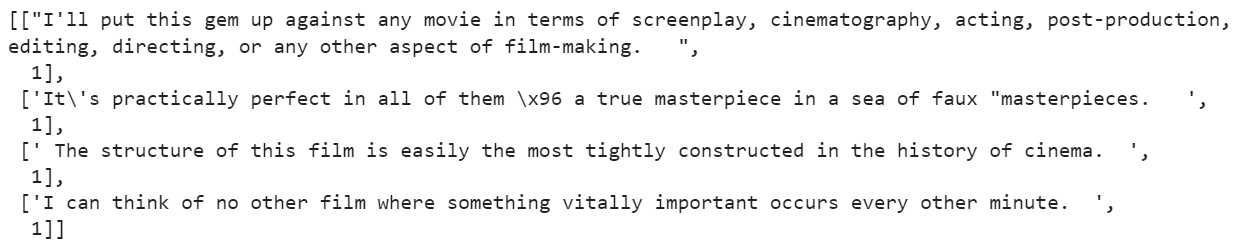

Transformemos en data frame la lista recién generada de los comentarios (review) y evaluaciones (label) del conjunto de evaluaciones de películas IMBD:

In [13]:
dfii = pd.DataFrame(newdfi, columns=['review','label'])

dfii.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  1000 non-null   object
 1   label   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


In [14]:
# y concatenamos los tres conjuntos para tener finalmente los 3000 registros:

df = pd.concat([dfa, dfii, dfy], ignore_index=True)   # Tienes que usar el "ignore_index", de lo contrario reincia cada 
                                                      # vez de 0 a 999 los índices.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  3000 non-null   object
 1   label   3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.0+ KB


La salida esperada anterior debe ser semajante a los siguiente:

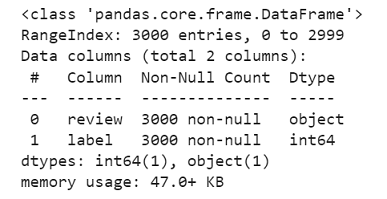

In [15]:
df['label'].value_counts()   # Recordemos que tenemos un 50% de comentarios positivos y de negativos.

0    1500
1    1500
Name: label, dtype: int64

In [16]:
df.head()

,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


##**Pregunta - 3:**

Sabemos que existen comentarios muy diversos. Por ejemplo, observa los registros 1125 y 1788, cuyas salidas deben de ser 10/10. De los 3000, dos de los comentarios fueron simplemente de esta forma.

Cuando apliques el proceso de limpieza en la pregunta 4, como solo consideraremos caracteres alfabéticos, estos dos registros quedarán vacíos.

En particular ¿cómo tratarías estos dos comentarios? ¿Simplemente los descartarías? ¿Los incluirías haciendo algún ajuste particular? ¿Alguna otra decisión que consideres adecuada para estos dos casos? 

**Incluye a continuación tus comentarios sobre la decisión que tomarías para el tratamiento en particular de estos dos registros, 1125 y 1788. Justifica tu respuesta.**

In [17]:
df.iloc[1788,:]   # verificando tu salida

review    10/10  
label           1
Name: 1788, dtype: object

########################################################
##### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 3:**


Considero que es aceptable incluir también los comentarios que tengan una califación numérica como 10/10 siempre y cuando tenga sentido esa califación y todos esos comentarios esten en la misma escala, pues si hay varias calificaciones con varias escalas y una persona lo califica con 5 del 1 al 5, y se escoge como referencia una escala del 1 al 10 entonces esa califación va a tener un sentido erróneo. Sin embargo, sigue siendo mejor los comentarios con palabras pues podemos obtener una información más amplia y al tener ya una lista de 3000 reviews pienso que no afecta mucho quitar dos reviews y obviamente nos reduce la complejidad de la limpieza y el análisis. Si estos reviews representaran un porcentaje alto en la lista entonces si se deberia trabajar con ellos. 


##### **FIN PARA AGREGAR TUS COMENTARIOS**
#########################################################

In [18]:
 # Separamos la información: 
 #     La "X" serán los datos de entrada, los comentarios.
 #     La "Y" será la variable de salida, la evaluación.
 # Ambos, X y Y son "Series" 

X = df.review     # Serie de strings
Y = df.label      # Serie de enteros 0s y 1s

assert X.shape == (3000,)           # verificando que tenemos la dimensiones esperadas.
assert Y.shape == (3000,)

##**Pregunta - 4:**

**En esta etapa deberás llevar a cabo el procesamiento, limpieza y tokenización de los comentarios de texto.**

Deberás de incluir los procesos que se indicarán a continuación, aunque no necesariament deben ser en este orden. De hecho deberás estar revisando la salida de algunos de los registros para que determines cual consideras podría ser el mejor orden de estos pasos.

La incluiremos en una función llamada "clean_tok()" ya que es la tokenización y limpieza básica de cada uno de los 3000 comentarios. La entrada de esta función son cada uno de estos 3000 strings/comentarios.

Lo que nos regresa "clean_tok()" es una lista de tokens/strings ya simplificados de cada comentario de entrada.

Los pasos a incluir son los siguientes (repito, tú deberás determinar el orden de ellos, aquí se incluyen en orden alfabético):

*   **Caracteres alfabéticos:** Solo considerar caracteres alfabéticos. Por lo tanto, deberán ser eliminados signos de puntuación, caracteres especiales y números.

*   **Longitud mayor a 1:** Se deben considerar solamente tokens de longitud mayor a 1.

*   **Minúsculas:** Simplificar todo a minúsculas.

*   **Stopwords:** Eliminar las stopwords.

*   **Tokenización:** Cada comentario queda tokenizado por palabras, o cadena de caracteres alfabéticos.

Por ejemplo, si el primer comentario de X fuera el string 'All you need is love!', lo que nos regresaría clean_tok() sería la lista de strings ['need', 'love'] que llamaremos "tokens".

In [19]:
def clean_tok(doc):
  ##############################################################################
  # AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 4:

  #tokenización
  reviews = nltk.sent_tokenize(doc)
  tokens =[]
  for rev in reviews:
    tokens.extend(nltk.word_tokenize(rev))
    
  tokens = re.sub(r'[^a-zA-ZáéíóúüñÁÉÍÓÚÜÑ]',' ',doc)  #solo caracteres alfabéticos 
  tokens = tokens.lower().split() #todo a minusculas

  tokens = [w for w in tokens if w not in mystopwords]  #eliminar stopwords 
  tokens = [w for w in tokens if not re.match(r'\b\w\b',w)]#longitud mayor a 1
  
  # FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
  ##############################################################################

  return tokens

In [20]:
# Aplicamos el proceso de limpieza y tokenización:

Xcleantok = [clean_tok(x) for x in X]   

Veamos los primeros comentarios.

En particular observa si "minutes" y "major" están como dos tokens separados en el cuarto comentario. De nos ser así, si aparecen juntos como un solo token, debes revisar tu proceso de limpieza anterior, porque esto significa que pueden existir otros muchos casos que nos llevan a esta salida no deseada. Trata de determinar el origen de este problema (y solo en caso de que te haya aparecido como un solo token "minutesmajor", en el cuarto comentario).


In [21]:
for x in Xcleantok[:9]:
  print(x)

['no', 'way', 'plug', 'us', 'unless', 'go', 'converter']
['good', 'case', 'excellent', 'value']
['great', 'jawbone']
['tied', 'charger', 'conversations', 'lasting', 'minutes', 'major', 'problems']
['mic', 'great']
['jiggle', 'plug', 'get', 'line', 'right', 'get', 'decent', 'volume']
['several', 'dozen', 'several', 'hundred', 'contacts', 'imagine', 'fun', 'sending', 'one', 'one']
['razr', 'owner', 'must']
['needless', 'say', 'wasted', 'money']


##**Pregunta - 5:**

Esta pregunta es abierta y podrás incluir todos aquellos procesos de limpieza adicionales que desees.

Por ejemplo, puedes decidir aplicar algunos procesos (regex) para simplificar caracteres que aparecen repetidos más de dos veces, o bien simplificar algunas conjugaciones de verbos regulares para no incluir terminaciones en "s", "ed" o "ing". Puedes también decidir aplicar alguna de las técnicas de stemming o de lemmatization, etc.

NOTA: Deberás aplicar al menos dos procesos de limpieza o normalización adicionales en esta función que llamamos simplemente clean_doc().

La entrada son cada una de las listas con los comentarios tokenizados de Xcleantok y la salida es una lista de tokens simplficados/normalizados con el nombre de "tokens". En dado caso, algunos de los comentarios tokenizados pudieran no surgir cambio alguno bajo esta función.

Recuerda que el objetivo de esta función "clean_doc()" es tener datos más limpios para el proceso de entrenamiento con los algoritmos de aprendizaje automático que se realizarán en las últimas preguntas.

Puedes inspeccionar de manera aleatoria algunos de los 3000 registros para determinar qué procesos de limpieza adicionales incluir.

In [22]:
for x in Xcleantok[:20]:
  print(x)

['no', 'way', 'plug', 'us', 'unless', 'go', 'converter']
['good', 'case', 'excellent', 'value']
['great', 'jawbone']
['tied', 'charger', 'conversations', 'lasting', 'minutes', 'major', 'problems']
['mic', 'great']
['jiggle', 'plug', 'get', 'line', 'right', 'get', 'decent', 'volume']
['several', 'dozen', 'several', 'hundred', 'contacts', 'imagine', 'fun', 'sending', 'one', 'one']
['razr', 'owner', 'must']
['needless', 'say', 'wasted', 'money']
['waste', 'money', 'time']
['sound', 'quality', 'great']
['impressed', 'going', 'original', 'battery', 'extended', 'battery']
['two', 'seperated', 'mere', 'ft', 'started', 'notice', 'excessive', 'static', 'garbled', 'sound', 'headset']
['good', 'quality', 'though']
['design', 'odd', 'ear', 'clip', 'not', 'comfortable']
['highly', 'recommend', 'one', 'blue', 'tooth', 'phone']
['advise', 'everyone', 'not', 'fooled']
['far', 'good']
['works', 'great']
['clicks', 'place', 'way', 'makes', 'wonder', 'long', 'mechanism', 'would', 'last']


In [23]:
from nltk.stem import PorterStemmer 

In [24]:
nltk.download('omw-1.4')   # paquete de nltk que ayuda en el proceso de stemming y lemmatization.

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [25]:
# creamos un objeto de la clase PorterStemmer
ps = PorterStemmer()

In [26]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 5:

def clean_doc(doc):
  #el stemming acepta palabras que en realidad no son palabras de un diccionario 
  tokens = [ps.stem(tokens) for tokens in doc] #eliminar terminaciones ed, ing, s, able, ly...
  tokens = [re.sub(r'(\w)\1{2,}', '', w) for w in tokens if not re.search(r'(\w)\1{2,}', w)] #eliminar palabras con caracteres repetipos mas de dos veces 

  return tokens
  # FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
  ##############################################################################

In [27]:
# Aplicamos el proceso de limpieza/normalización adicionales:

Xclean = [clean_doc(x) for x in Xcleantok]  

In [28]:
Xclean[:20]         # Veamos los primero registros para ver cómo va quedando el resultado.

[['no', 'way', 'plug', 'us', 'unless', 'go', 'convert'],
 ['good', 'case', 'excel', 'valu'],
 ['great', 'jawbon'],
 ['tie', 'charger', 'convers', 'last', 'minut', 'major', 'problem'],
 ['mic', 'great'],
 ['jiggl', 'plug', 'get', 'line', 'right', 'get', 'decent', 'volum'],
 ['sever',
  'dozen',
  'sever',
  'hundr',
  'contact',
  'imagin',
  'fun',
  'send',
  'one',
  'one'],
 ['razr', 'owner', 'must'],
 ['needless', 'say', 'wast', 'money'],
 ['wast', 'money', 'time'],
 ['sound', 'qualiti', 'great'],
 ['impress', 'go', 'origin', 'batteri', 'extend', 'batteri'],
 ['two',
  'seper',
  'mere',
  'ft',
  'start',
  'notic',
  'excess',
  'static',
  'garbl',
  'sound',
  'headset'],
 ['good', 'qualiti', 'though'],
 ['design', 'odd', 'ear', 'clip', 'not', 'comfort'],
 ['highli', 'recommend', 'one', 'blue', 'tooth', 'phone'],
 ['advis', 'everyon', 'not', 'fool'],
 ['far', 'good'],
 ['work', 'great'],
 ['click',
  'place',
  'way',
  'make',
  'wonder',
  'long',
  'mechan',
  'would',
  'la

##**Pregunta - 6:**

En esta pregunta deberás generar la nube de palabras de cada clase: la de los comentarios positivos y la de los comentarios negativos.

En la primera parte de esta pregunta y a partir del conjunto de comentarios obtenido hasta ahora, Xclean, deberás obtener el string de comentarios positivos llamada "pt" y el de comentarios negativos "nt".

En la parte 2 deberás mostrar las dos nubes de palabras: la nube de palabras de los comentarios positivos y la nube de palabras de los comentarios negativos.

En la parte 3 de este ejercicio deberás incluir tus comentarios de lo que observas de ambas nubes de palabras.

Igualmente deberás incluir los paquetes o librerías necesarios.

In [29]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 6 - parte 1:

from wordcloud import WordCloud
import matplotlib.pyplot as plt

pos_tok=[]  # inicializamos listas de los tokens positivos y negativos
neg_tok=[]

for x,c in zip(Xclean, Y):   
  if c==1:
    pos_tok.extend(x)   # tokens usados en comentarios positivos
  else: 
    neg_tok.extend(x)   # tokens usados en comentarios negativos

pt = ' '.join(pos_tok) 
nt = ' '.join(neg_tok) 
print("String de comentarios positivos:", pt)
print("String de comentarios negativos:", nt)
# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

String de comentarios positivos: good case excel valu great jawbon mic great razr owner must sound qualiti great impress go origin batteri extend batteri good qualiti though highli recommend one blue tooth phone far good work great bought use kindl fire absolut love yet run new batteri two bar three day without charg great pocket pc phone combin own phone month say best mobil phone product ideal peopl like whose ear sensit car charger well ac charger includ make sure never run juic highi recommend kept well case great work fine great camera that mp pic nice clear great pictur qualiti nice headset price right excel bluetooth headset featur want case seem well made good protect not make phone bulki usabl keyboard actual turn pda real world use machin instead neat gadget phone pretti sturdi never larg problem love thing everyth fine reason price even drop phone stream submerg second still work great happi no complaint one regard sound qualiti end realli recommend facepl sinc look nice ele

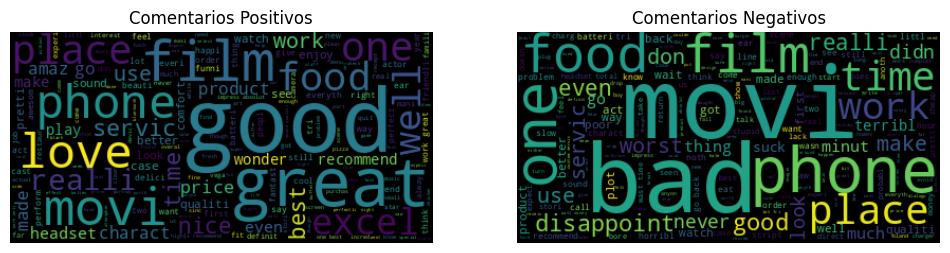

In [30]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 6 - parte 2:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,12))

# Nube de palabras de comentarios positivos:
wordcloudnn = WordCloud().generate(pt)
ax1.imshow(wordcloudnn, interpolation='bilinear')
ax1.axis("off")
ax1.set_title('Comentarios Positivos')

# Nube de palabras de comentarios negativos:
wordcloudnn = WordCloud().generate(nt)
ax2.imshow(wordcloudnn, interpolation='bilinear')
ax2.axis("off")
ax2.set_title('Comentarios Negativos')

plt.show()

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################


###### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 6 - parte 3:**

Con estas dos nubes de palabras podemos observar las palabras que mas aparecen en cada tipo de comentario. Estas nubes de palabras arrojaron resultados bastante lógicos ya que por ejemplo cuando queremos dar un buen comentario sobre algún producto o servicio que nos gustó siempre utilizamos las palabras en inglés como "good", "great", "love", "best" etc y en la nube de comentarios positivos se pueden apreciar perfectamente. 

Por otro lado en la nube de comentarios negativos podemos distinguir palabras negativas como "bad", "disappoint", "never", "worst", "terribl", "suck", entre otras. 

Obviamente hay palabras que pueden aparecen en los dos tipos de comentarios ya que pueden ser el objeto o servicio del que estan hablando, por ejemplo "phone" o "food", o que por ejemplo la persona que escribió el review este calificando varios de los aspectos de un producto y dice solo algo bueno del producto pero todo lo demás lo califica como malo entonces en general es un comentario negativo y por lo tanto la única cosa positiva que dijo va a añadirse como string negativa también. 

En general creo que nos dió muy buenos resultados y es una buena manera de observar resumidamente nuestros strings. 

###**Train-Validation-Test**

Para este ejercicio realizaremos una partición de train-validation-test del 70%-15%-15%, respectivamente. 

Obviamente la distribución de esta partición puede ser otro de los hiperparámetros a determinar, pero para fines de este ejercicio consideraremos dichos valores.

In [31]:
from sklearn.model_selection import train_test_split

x_train, x_val_and_test, y_train, y_val_and_test = train_test_split(Xclean, Y, train_size=.70, shuffle=True, random_state=1) 
x_val, x_test, y_val, y_test = train_test_split(x_val_and_test, y_val_and_test, test_size=.50, shuffle=True, random_state=17)

print('X,y Train:', len(x_train), len(y_train))      # los "x_" son "list" y los "y_" son "Series"
print('X,y Val:', len(x_val), len(y_val))
print('X,y Test', len(x_test), len(y_test))

X,y Train: 2100 2100
X,y Val: 450 450
X,y Test 450 450


###Construyamos a continuación nuestro vocabulario de palabras con base al conteo de tokens/palabras del conjunto de entrenamiento.

In [32]:
from collections import Counter

In [33]:
midiccionario = Counter()    

for k in range(len(x_train)):
  midiccionario.update(x_train[k])


print('Longitud del diccionario:', len(midiccionario))  
print('\n(word,frequency):') 
print(midiccionario.most_common(10)) 

Longitud del diccionario: 3154

(word,frequency):
[('not', 218), ('good', 164), ('movi', 140), ('great', 139), ('phone', 134), ('film', 130), ('work', 113), ('time', 102), ('like', 101), ('one', 100)]


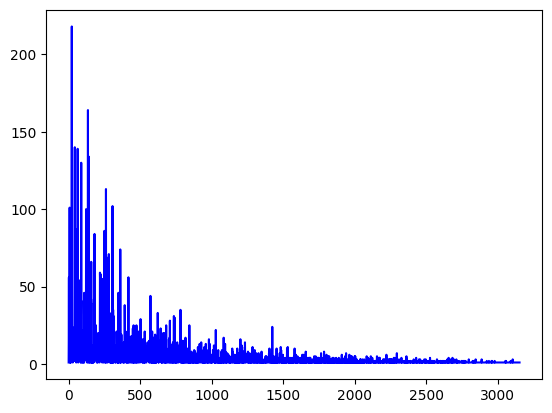

In [34]:
# Veamos la gráfica de palabras nuestro diccionario con base a la frecuencia de las palabras/tokens:

plt.plot(list(np.arange(len(midiccionario))), list(midiccionario.values()), color='blue')
plt.show()

###Descartemos palabras cuya frecuencia en el conjunto de entrenamiento es muy pequeña:

##**Pregunta - 7:**

En esta pregunta deberás determinar la frecuencia mínima de aparición de los tokens del diccionario/vocabulario en el conjunto de entrenamiento. Es usual que al menos se filtren los tokens de frecuencia 1, ya que usualmente no dan mayor información.

Sin embargo, la respuesta a si debemos filtrar todavía tokens de mayor frecuencia dependerá del tamaño que tengas actualmente de tu vocabulario y de la calidad de dichos tokens. Una manera de determinar dicha calidad de los tokens es con el resultado de los modelos de aprendizaje (regresión logística, random-forest, etc.) que aplicarás en los ejercicios de la última parte de esta Actividad.

Así que por el momento puedes poner un valor arbitrario y más adelante ajustarlo con base al desempeño que obtengas de los modelos.

Sin embargo, debes cuidar que la frecuencia de los tokens no la consideres demasiado grande, que empieces a generar una gran cantidad de comentarios vacíos en tu conjunto de entrenamiento.

Llamaremos "min_freq" a la frecuencia mínima de aparición de un token para considerarlo dentro del vocabulario/diccionario. Debe ser un número entero.

Llamaremos "midicc" al nuevo diccionario que generes con tokens de frecuencia natural (es decir, de conteo) mayor o igual a "min_freq".

In [35]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 7:

min_freq = 5

midicc = Counter()    

for word, frequency in midiccionario.items(): 
  if frequency > min_freq:
    midicc[word] = frequency #en el midicc se agregan solo los que van cumpliendo con la condicion 

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
############################################################################## 
print('Nueva longitud del nuevo vocabulario:', len(midicc))
print(list(midicc.items())[0:5])     # veamos algunos elementos del diccionario.

Nueva longitud del nuevo vocabulario: 469
[('star', 18), ('don', 56), ('much', 39), ('better', 38), ('peopl', 23)]


###Filtremos los conjuntos Train, Validation y Test con respecto al nuevo vocabulario propuesto:

In [36]:
train_x = []
for ss in x_train:
  train_x.append([w for w in ss if w in midicc])

val_x = []
for ss in x_val:
  val_x.append([w for w in ss if w in midicc])

test_x = []
for ss in x_test:
  test_x.append([w for w in ss if w in midicc])

In [37]:
# Podemos ver algunos de los comentarios de entrenamiento, antes y después 
# de incluir la condición de la frecuencia mínima de ocurrencia de un token:

for k in range(3):
  print('Antes:', x_train[k])
  print('Después:', train_x[k])

Antes: ['co', 'star', 'don', 'fare', 'much', 'better', 'peopl', 'like', 'morgan', 'freeman', 'jonah', 'hill', 'ed', 'helm', 'wast']
Después: ['star', 'don', 'much', 'better', 'peopl', 'like', 'wast']
Antes: ['tonight', 'elk', 'filet', 'special', 'suck']
Después: ['special', 'suck']
Antes: ['paid', 'bill', 'not', 'tip', 'felt', 'server', 'terribl', 'job']
Después: ['not', 'felt', 'server', 'terribl', 'job']


###Obtengamos las matrices de conteo document-term-matrix como matrices dispersas (sparse matrices ). Para ello requerimos que cada comentario esté como un solo string.

In [38]:
train_x_docs = []
for k in range(len(train_x)):
  train_x_docs.append(' '.join(train_x[k]))

val_x_docs = []
for k in range(len(val_x)):
  val_x_docs.append(' '.join(val_x[k]))

test_x_docs = []
for k in range(len(test_x)):
  test_x_docs.append(' '.join(test_x[k]))



# Verifica que los primeros comentarios de Train están cada uno como un solo string:
for k in range(3):
  print(train_x_docs[k])

star don much better peopl like wast
special suck
not felt server terribl job


###Ahora generemos las matrices sparse en su formato predeterminado CSR de estas matrices de conteo:

In [39]:
mivocab = list(midicc.keys())     # Obtenemos nuestro vocabulario de tokens/palabras.

#mivocab.sort()    # Usualmente se ordenan alfabéticamente, pero para visualizar algunos de los valores 
                   # no cero de las matrices, por el momento no lo haremos.



# Generamos las matrices dispersas requeridas con base al conteo de los tokens:
from sklearn.feature_extraction.text import CountVectorizer

countvectorizer = CountVectorizer(vocabulary=mivocab)
train_x_count = countvectorizer.fit_transform(train_x_docs)     
val_x_count = countvectorizer.transform(val_x_docs) 
test_x_count = countvectorizer.transform(test_x_docs)

count_tokens = countvectorizer.get_feature_names_out()
df_countvect = pd.DataFrame(data = train_x_count.toarray(),  columns = count_tokens)  
print(df_countvect.iloc[0:3,6:18])   # veamos las frecuencias de los primeros comentarios.

   wast  special  suck  not  felt  server  terribl  job  call  cook  steak  \
0     1        0     0    0     0       0        0    0     0     0      0   
1     0        1     1    0     0       0        0    0     0     0      0   
2     0        0     0    1     1       1        1    1     0     0      0   

   understand  
0           0  
1           0  
2           0  


In [40]:
p_sparse = 1 - train_x_count.count_nonzero() / (train_x_count.shape[0] * train_x_count.shape[1])    # Sparsity : Porcentaje de valores de 0.
print('Porcentaje de valores cero de la matriz sparse de entrenamiento: %.1f%%' % (100*p_sparse))

Porcentaje de valores cero de la matriz sparse de entrenamiento: 99.2%


##**Pregunta - 8:**

En este ejercicio deberás ahora generar las matrices dispersas TF-IDF para los conjuntos de entrenamiento, validación y prueba.

Deberás usar el vocabulario "mivocab" para generar dichas matrices.

Dichas matrices las llamaremos "train_x_tfidf", "val_x_tfidf" y "test_x_tfidf".

Deberás agregar además las librerías o módulos necesarios. 

Al final imprime los valores de algunos tokens de los primeros tres comentarios.

In [41]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 8:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidfvectorizer = TfidfVectorizer(vocabulary=mivocab, norm=None)#vocabulario
tfidf_tokens = tfidfvectorizer.get_feature_names_out()#nombres

#matriz TF-IDF entrenamiento 
DTM_train_tfidf = tfidfvectorizer.fit_transform(train_x_docs)  
train_x_tfidf = pd.DataFrame(data = DTM_train_tfidf.toarray(),  columns = tfidf_tokens)  
print("Matriz dispersa TF-IDF para Entrenamiento")
print(train_x_tfidf.iloc[0:3,0:]) 


#matriz TF-IDF validacion 
DTM_val_tfidf = tfidfvectorizer.fit_transform(val_x_docs)  
val_x_tfidf = pd.DataFrame(data = DTM_val_tfidf.toarray(),  columns = tfidf_tokens) 
print("Matriz dispersa TF-IDF para Validación") 
print(val_x_tfidf.iloc[0:3,0:]) 



#matriz TF-IDF prueba
DTM_test_tfidf = tfidfvectorizer.fit_transform(test_x_docs)  
test_x_tfidf = pd.DataFrame(data = DTM_test_tfidf.toarray(),  columns = tfidf_tokens) 
print("Matriz dispersa TF-IDF para Prueba") 
print(test_x_tfidf.iloc[0:3,0:]) 



# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

Matriz dispersa TF-IDF para Entrenamiento
       star       don      much    better     peopl      like      wast  \
0  5.759797  4.661185  4.986607  5.039251  5.514674  4.096292  5.153661   
1  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
2  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   

    special      suck       not  ...  brilliant  hate  sever  fast  goe  \
0  0.000000  0.000000  0.000000  ...        0.0   0.0    0.0   0.0  0.0   
1  6.011111  5.605646  0.000000  ...        0.0   0.0    0.0   0.0  0.0   
2  0.000000  0.000000  3.322293  ...        0.0   0.0    0.0   0.0  0.0   

   superb  locat  own  weak  insid  
0     0.0    0.0  0.0   0.0    0.0  
1     0.0    0.0  0.0   0.0    0.0  
2     0.0    0.0  0.0   0.0    0.0  

[3 rows x 469 columns]
Matriz dispersa TF-IDF para Validación
   star  don  much  better  peopl  like  wast  special  suck  not  ...  \
0   0.0  0.0   0.0     0.0    0.0   0.0   0.0      0.0   0.0  0.0  ... 

##**Pregunta - 9:**

####A continuación, usando Sklearn, deberás aplicar los modelos de regresión logística (lo llamaremos modeloLRcount), ranfom-forest para clasificación (lo llamaremos modeloRFcount) y naive-bayes en su opción MultinomialNB (lo llamaremos modeloNBcount). 

####Deberás de utilizar las matrices de conteo "train_x_count", "val_x_count" y "test_x_count".

####Con el mejor modelo obtenido, se usará el conjunto de prueba (test) para obtener el desempeño (Accuracy) final y su matriz de confusión.

####Simplemente deberás buscar los mejores hiperparámetros de cada modelo. 

####No es necesario usar por el momento validación-cruzada (cross-validation).

####Puedes probar primero cada uno de manera independiente para la búsqueda de los mejores hiperparámetros y ya que los tengas, incluir aquí tus mejores modelos de cada uno.

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV

In [43]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 9:

#Logistic Regression

dicc_gridLR = [{'penalty':['l1'],
             'C':[0.0001,0.01,0.1,1.0,10.,100.],
             'solver':['saga'],
             'class_weight':['balanced', None],
                          },
            {'penalty':['l2'],
             'C':[0.0001,0.01,0.1,1.0,10.,100.],
             'solver':['newton-cg','lbfgs','liblinear','sag','saga'],
             'class_weight':['balanced', None],
                          },
             {'penalty':['elasticnet'],
             'C':[0.0001,0.01,0.1,1.0,10.,100.],
             'solver':['saga'],
             'class_weight':['balanced', None],
             'l1_ratio': [0.5],
                          }]

gridLR = GridSearchCV(estimator=LogisticRegression(max_iter=10000,random_state=42), 
                    param_grid=dicc_gridLR)



gridLR.fit(train_x_count, y_train)

modeloLRcount = gridLR.best_estimator_



# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

print('Mejor combinación de valores encontrados de los hiperparámetros:', gridLR.best_params_)
print('LR: Train-accuracy: %.2f%%' % (100*modeloLRcount.score(train_x_count, y_train)))
print('LR: Val-accuracy: %2.f%%' % (100*modeloLRcount.score(val_x_count, y_val)))

Mejor combinación de valores encontrados de los hiperparámetros: {'C': 1.0, 'class_weight': None, 'penalty': 'l2', 'solver': 'newton-cg'}
LR: Train-accuracy: 88.00%
LR: Val-accuracy: 83%


In [44]:
#Random Forest

dicc_gridRFC = { 'ccp_alpha':[0.1, .01, .001,.0001],
              'criterion':['gini','entropy'],
              'max_depth':[2,4,6,8,10,12],
              'min_samples_split':[2,4,6,8,10,12],
              'class_weight':['balanced',None],
                           } 

gridRFC = GridSearchCV(estimator=RandomForestClassifier(random_state=0), 
                    param_grid=dicc_gridRFC)

gridRFC.fit(train_x_count, y_train)

modeloRFcount = gridRFC.best_estimator_

print('Mejor combinación de valores encontrados de los hiperparámetros:', gridRFC.best_params_)
print('\nRF: Train-accuracy: %.2f%%' % (100*modeloRFcount.score(train_x_count, y_train)))
print('RF: Val-accuracy: %.2f%%' % (100*modeloRFcount.score(val_x_count, y_val)))

Mejor combinación de valores encontrados de los hiperparámetros: {'ccp_alpha': 0.0001, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 12, 'min_samples_split': 8}

RF: Train-accuracy: 81.90%
RF: Val-accuracy: 79.78%


In [45]:
#Multinomial NB

dicc_gridNB = { 'alpha':[1, 0.1, 0.01, 0.001, 0.0001, 0.00001],
              'fit_prior':[True,False],
              'force_alpha':[True,False]
                           } 

gridNB = GridSearchCV(estimator=MultinomialNB(), 
                    param_grid=dicc_gridNB)

gridNB.fit(train_x_count, y_train)

modeloNBcount = gridNB.best_estimator_

print('Mejor combinación de valores encontrados de los hiperparámetros:', gridNB.best_params_)
print('\nNB: Train-accuracy: %.2f%%' % (100*modeloNBcount.score(train_x_count, y_train)))
print('NB: Val-accuracy: %.2f%%' % (100*modeloNBcount.score(val_x_count, y_val)))

Mejor combinación de valores encontrados de los hiperparámetros: {'alpha': 1, 'fit_prior': True, 'force_alpha': True}

NB: Train-accuracy: 84.76%
NB: Val-accuracy: 80.89%


In [46]:
##############################################################################
# AGREGA AQUÍ EL NOMBRE DE TU MEJOR MODELO OBTENIDO CON COUNTER:

mejor_modelo_Count = modeloLRcount # incluye el nombre, modeloXXcount, de tu mejor modelo.

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################



print('Test-accuracy con el mejor modelo de Conteo %.2f%%' % (100*mejor_modelo_Count.score(test_x_count, y_test)))

from sklearn.metrics import confusion_matrix

pred = mejor_modelo_Count.predict(test_x_count)
print('\nMatriz de confusión con el mejor modelo de Conteo:')
print(confusion_matrix(y_test, pred, labels=[0,1]))

print('\nMatriz de confusión con el mejor modelo de Conteo en proporciones:')
print(confusion_matrix(y_test, pred, labels=[0,1]) / pred.shape[0])

Test-accuracy con el mejor modelo de Conteo 80.44%

Matriz de confusión con el mejor modelo de Conteo:
[[181  35]
 [ 53 181]]

Matriz de confusión con el mejor modelo de Conteo en proporciones:
[[0.40222222 0.07777778]
 [0.11777778 0.40222222]]


##**Pregunta - 10:**

###Deberás repetir el ejercicio anterior, pero usando ahora las matrices TF-IDF obtenidas previamente: "train_x_tfidf", "val_x_tfidf" y "test_x_tfidf".

###Llamaremos a los modelos modeloXXtfidf, para LR, RF y NB.

In [47]:
#Logistic Regression
gridLR_TFIDF = GridSearchCV(estimator=LogisticRegression(max_iter=10000,random_state=42), 
                    param_grid=dicc_gridLR)



gridLR_TFIDF.fit(train_x_tfidf, y_train)

modeloLRtfidf = gridLR_TFIDF.best_estimator_



# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################
print('Resultados parciales con matrices tf-idf:')
print('Mejor combinación de valores encontrados de los hiperparámetros:', gridLR_TFIDF.best_params_)
print('LR: Train-accuracy: %.2f%%' % (100*modeloLRtfidf.score(train_x_tfidf, y_train)))
print('LR: Val-accuracy: %2.f%%' % (100*modeloLRtfidf.score(val_x_tfidf, y_val)))

Resultados parciales con matrices tf-idf:
Mejor combinación de valores encontrados de los hiperparámetros: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'newton-cg'}
LR: Train-accuracy: 87.05%
LR: Val-accuracy: 82%


In [48]:
#Random Forest
gridRFC = GridSearchCV(estimator=RandomForestClassifier(random_state=0), 
                    param_grid=dicc_gridRFC)

gridRFC.fit(train_x_tfidf, y_train)

modeloRFtfidf = gridRFC.best_estimator_

print('Resultados parciales con matrices tf-idf:')
print('Mejor combinación de valores encontrados de los hiperparámetros:', gridRFC.best_params_)
print('\nRF: Train-accuracy: %.2f%%' % (100*modeloRFtfidf.score(train_x_tfidf, y_train)))
print('RF: Val-accuracy: %.2f%%' % (100*modeloRFtfidf.score(val_x_tfidf, y_val)))

Mejor combinación de valores encontrados de los hiperparámetros: {'ccp_alpha': 0.0001, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 12, 'min_samples_split': 12}

RF: Train-accuracy: 81.52%
RF: Val-accuracy: 79.78%


In [50]:
#Multinomial NB 

gridNB = GridSearchCV(estimator=MultinomialNB(), param_grid=dicc_gridNB)

gridNB.fit(train_x_tfidf, y_train)

modeloNBtfidf = gridNB.best_estimator_

print('Resultados parciales con matrices tf-idf:')
print('Mejor combinación de valores encontrados de los hiperparámetros:', gridNB.best_params_)
print('\nNB: Train-accuracy: %.2f%%' % (100*modeloNBtfidf.score(train_x_tfidf, y_train)))
print('NB: Val-accuracy: %.2f%%' % (100*modeloNBtfidf.score(val_x_tfidf, y_val)))

Resultados parciales con matrices tf-idf:
Mejor combinación de valores encontrados de los hiperparámetros: {'alpha': 1, 'fit_prior': True, 'force_alpha': True}

NB: Train-accuracy: 84.86%
NB: Val-accuracy: 78.89%


In [54]:
##############################################################################
# AGREGA AQUÍ EL NOMBRE DE TU MEJOR MODELO OBTENIDO CON TF-IDF:

mejor_modelo_Tfidf = modeloNBtfidf # incluye el nombre, modeloXXtfidf, de tu mejor modelo.

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################



print('Test-accuracy con el mejor modelo Tf-idf %.2f%%' % (100*mejor_modelo_Tfidf.score(test_x_tfidf, y_test)))

pred = mejor_modelo_Tfidf.predict(test_x_tfidf)
print('\nMatriz de confusión con el mejor modelo Tf-idf:')
print(confusion_matrix(y_test, pred, labels=[0,1]))

print('\nMatriz de confusión con el mejor modelo de Tf-idf en proporciones:')
print(confusion_matrix(y_test, pred, labels=[0,1]) / pred.shape[0])

Test-accuracy con el mejor modelo Tf-idf 80.00%

Matriz de confusión con el mejor modelo Tf-idf:
[[179  37]
 [ 53 181]]

Matriz de confusión con el mejor modelo de Tf-idf en proporciones:
[[0.39777778 0.08222222]
 [0.11777778 0.40222222]]


##**Pregunta - 11:**

###Finalmente incluye tus conclusiones finales de la Actividad. 

###En particular, indica cuál técnica resultó mejor en este problema, ¿usando matrices de conteo o tf-idf?

###Indica también a qué crees que se debe la diferencia entre los valores de los Falsos-Negativos y Falsos-Positivos de la mejor matriz de confusión que obtuviste. ¿Qué implicaciones podrían tener cada uno de estos errores?

##**Como nota complementaria, se esperaría que tu mejor modelo final mínimamente debiera alcanzar un 72% de buen desempeño (accuracy), pero puede ser mayor.**

######################################################################
###### **CONCLUSIONES:**

Para este conjunto de comentarios en específico, las matrices usando Regresión Logística tuvieron una desempeño mayor que las de Random Forest y Multinomial NB cuando se entrenó con las partes de entrenamiento y validación.

Considero que las matrices de conteo sería mejor opción utilizar simplemente porque en este caso nos interesa más conocer las palabras clave para ubicar la clase de cada texto y no tanto la agrupación de temas, que es uno de los principales objetivos de las matrices TD-IDF. Sin embargo, para este caso, tanto las de Conteo y TF-IDF tuvieron un desempeño muy similar para los tres casos, aproximadamente solo un 1% de diferencia, así que usar tambien las otras no no trae ningún problema. 

Para los datos de prueba, elegí la de Regresión Logística en las matrices de Conteo. Para las TF-IDF utilicé Multinomial Naive Bayes ya que la este y la de regresión logística daban el mismo desempeño de 80% pero la de regresión logística duró aproximadamente 1 hora y media en correr y la de Multinomial NB solo unos dos minutos. 

Respecto a las matrices de confusión obtenidas, los porcentajes de Verdaderos Positivos y Verdaderos Negativos son bastante buenos, solo puedo decir que la cantidad de Falsos Negativos es mucho mayor que la de Falsos Positivos, o sea que modelo a veces se equivoca en contar los comentarios positivos como negativos, es decir, que hay palabras en dichos comentarios positivos que a lo mejor no son muy relevantes o muy comunes en los comentarios positivos, o que pueden utilizarse también para escribir un review negativo y por eso se equivoca. Por otro lado sabemos que casi todos los comentarios negativos los clasifica como tal, y podemos decir que hay palabras negativas que casi nunca se utilizan para decir algo bueno por lo que automaticamente nos dice que se trata de un review malo. 

Para un negocio tener un buena evaluación de un cliente le trae muchos beneficios y para casos como el de ventas de productos en Amazon o servicios de comida, contar con Falsos Negativos puede afectar a la imagen o reputación de la marca e incluso que la lealtad o preferencia del cliente cambie para mal. 

Por otro lado, aunque sean pocos, los falsos positivos también puede ser problemático ya que les da a los demás clientes una falsa idea de lo que es un producto o servicio, y cuando lleguen a utilizarlo pueden resultar decepcionados. 

######################################################################

#**FIN DE LA ACTIVIDAD DE LAS SEMANAS 3 Y 4**